## L96 Experiments

The purpose of this notebook is to first test how long I should expect some long L96 experiments to take with kernel embeddings NLE, and then potentially to actually run those experiments out long here (or on orion depending on how long we're talking about).

In [1]:
import numpy as np 
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh
from scipy.stats import norm, cauchy

reload(dap)

np.set_printoptions(suppress=True)


ModuleNotFoundError: No module named 'DAPyr'

In [2]:
poep = {'mu': 0, 'sigma': 2.0} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [3]:
e_name = 'L96: Cauchy'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

e_sd_gaussian = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 1,
                      'prescribed_obs_err': 0,
                      'used_obs_err_params': uoep_sd,
                      'prescribed_obs_err_params': poep,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_sd_true = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 1,
                      'prescribed_obs_err': 1,
                      'used_obs_err_params': uoep_sd,
                      'prescribed_obs_err_params': poep_sd,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_ch_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

e_ch_gaussian = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 0,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_gaus_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_ch_true = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 3,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_ch_kecd_big = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': 0.2,
                       'bw_dm': 0.05,
                       'klb':klb,
                       'debug_nle_noDA': False})

e_ch_kecd_small = dap.Expt(e_name, {'expt_flag': 3,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 0,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_gaus_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': 0.05,
                      'bw_dm': 0.01,
                      'klb':klb,
                      'debug_nle_noDA': False})


starting experiment L96: Cauchy


In [4]:
e_ch_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_ch_gaussian = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 0,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_gaus_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_ch_true = dap.Expt(e_name, {'expt_flag': 1,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 3,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': knn,
                      'bw_dm': bw,
                      'klb':klb,
                      'debug_nle_noDA': False})
e_ch_kecd_big = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2500,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': 0.2,
                       'bw_dm': 0.05,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_ch_kecd_small = dap.Expt(e_name, {'expt_flag': 3,
                      'model_flag':1,
                      'localize':1,
                      'obf': 2,
                      'seed': 58,
                      'qc_flag': 0,
                      'used_obs_err': 3,
                      'prescribed_obs_err': 0,
                      'used_obs_err_params': uoep_cauchy,
                      'prescribed_obs_err_params': poep_gaus_cauchy,
                      'save_keest_pab':1,
                      'Ne':80,
                      'T': 2500,
                      'T_train': 400,
                      'nle_type': 5,
                      'nle_every': 50, 
                      'Neig': 50,
                      'knn_frac': 0.05,
                      'bw_dm': 0.01,
                      'klb':klb,
                      'debug_nle_noDA': False})


In [4]:
#print('starting e_sd_kecd')
#dap.runDA(e_sd_kecd)
print('starting e sd gaus')
dap.runDA(e_sd_gaussian)
print('starting e sd true')
dap.runDA(e_sd_true)
#print('starting e ch kecd')
#dap.runDA(e_ch_kecd)
#print('starting ch gaus')
#dap.runDA(e_ch_gaussian)
#print('starting ch true')
#dap.runDA(e_ch_true)
#print('starting e_ch_kecd_big')
#dap.runDA(e_ch_kecd_big)
#print('starting e_ch_kecd_small')
#dap.runDA(e_ch_kecd_small)
#fig, ax = plt.subplots()
#dap.plot_pab(e_sd_kecd, ax=ax, plot_states=True)
#ax.plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=4.08, scale=0.75), linewidth=2, linestyle='dotted', c='k')

starting e sd gaus
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
DB: Starting cycle 1500
DB: Starting cycle 1600
DB: Starting cycle 1700
DB: Starting cycle 1800
DB: Starting cycle 1900
DB: Starting cycle 2000
DB: Starting cycle 2100
DB: Starting cycle 2200
DB: Starting cycle 2300
DB: Starting cycle 2400
starting e sd true
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
DB: Starting cycle 1500
DB

'completed'

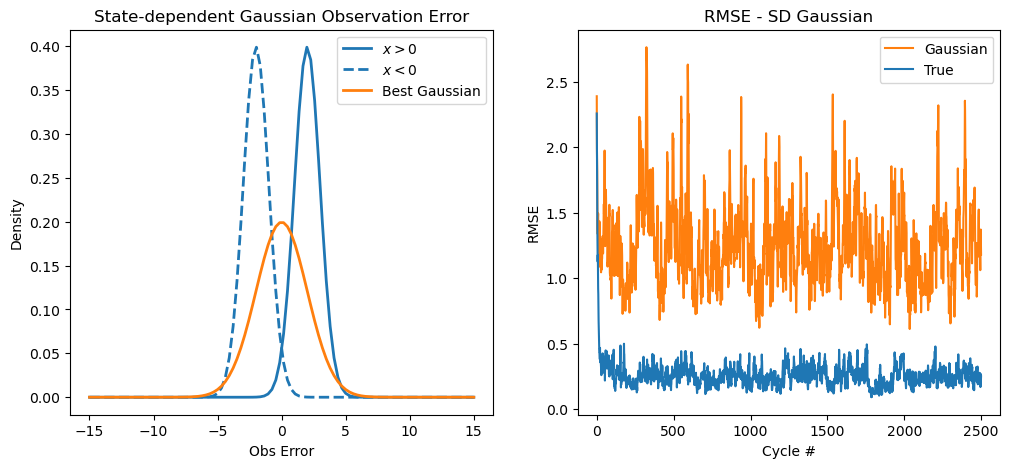

In [6]:
fig, axs = plt.subplots(1,2, figsize=(12,5), sharey='col', sharex='col')
axs[0].set_title('State-dependent Gaussian Observation Error')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=2, scale=1), linewidth=2, c='C0', label='$x > 0$')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=-2, scale=1), linewidth=2, linestyle='dashed', c='C0', label='$x < 0$')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=0, scale=2), linewidth=2, c='C1', label='Best Gaussian')
axs[0].set_ylabel('Density')
axs[0].set_xlabel('Obs Error')
axs[0].legend()

axs[1].plot(e_sd_gaussian.rmse, label='Gaussian', c='C1')
axs[1].plot(e_sd_true.rmse, label='True', c='C0')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE - SD Gaussian')
axs[1].set_xlabel('Cycle #')
axs[1].legend()

plt.savefig('sdobserr.png')



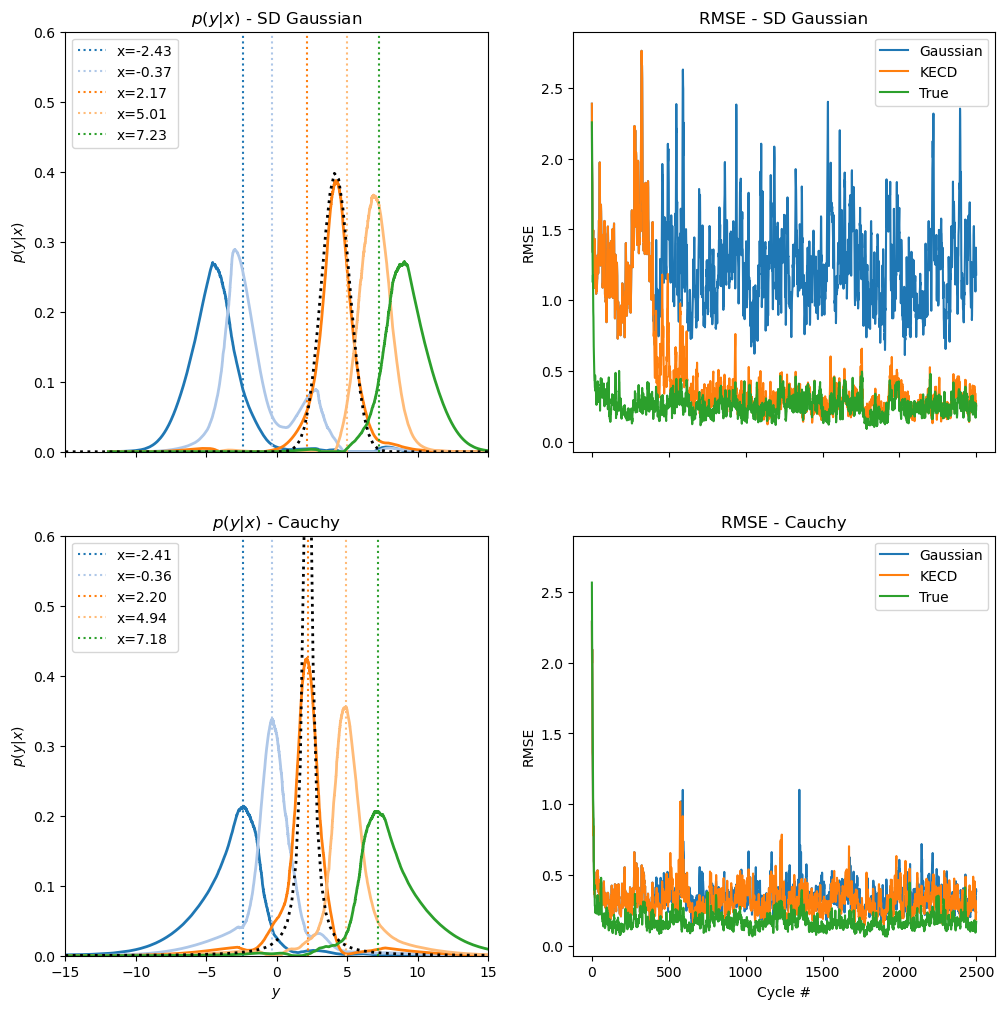

<Figure size 640x480 with 0 Axes>

In [81]:
fig, axs = plt.subplots(2,2, figsize=(12,12), sharey='col', sharex='col')
dap.plot_pab(e_sd_kecd, ax=axs[0,0], plot_states=True)
axs[0,0].set_title('$p(y|x)$ - SD Gaussian')
#dap.plot_pab(e_lg_kecd, ax=axs[1,0], plot_states=True)
axs[0,0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=4.17, scale=1), linewidth=2, linestyle='dotted', c='k')
dap.plot_pab(e_ch_kecd, ax=axs[1,0], plot_states=True)
#axs[1,0].set_title('$p(y|x)$ - Logistic')
#axs[1,0].plot(np.linspace(-15, 15, 100), logistic.pdf(np.linspace(-15, 15, 100), loc=2.15, scale=1.0), linewidth=2, linestyle='dotted', c='k')
axs[1,0].set_title('$p(y|x)$ - Cauchy')
axs[1,0].plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.20, scale=0.34), linewidth=2, linestyle='dotted', c='k')
#dap.plot_pab(e7, ax=axs[2,0], plot_states=True)
#axs[2,0].set_title('$p(y|x)$ - Cauchy, Poor Tuning')
#axs[2,0].plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.18, scale=0.2), linewidth=2, linestyle='dotted', c='k')
axs[1,0].set_ylim(0,0.6)

axs[0,1].plot(e_sd_gaussian.rmse, label='Gaussian')
axs[0,1].plot(e_sd_kecd.rmse, label='KECD')
axs[0,1].plot(e_sd_true.rmse, label='True')
axs[0,1].set_ylabel('RMSE')
axs[0,1].set_title('RMSE - SD Gaussian')
axs[0,1].legend()

#axs[1,1].plot(e_lg_kecd.rmse, label='KECD')
#axs[1,1].plot(e_lg_gaussian.rmse, label='Gaussian')
#axs[1,1].plot(e_lg_true.rmse, label='True')
#axs[1,1].set_ylabel('RMSE')
#axs[1,1].set_title('RMSE - Logistic')
#axs[1,1].legend()

axs[1,1].plot(e_ch_gaussian.rmse, label='Gaussian')
axs[1,1].plot(e_ch_kecd.rmse, label='KECD')
axs[1,1].plot(e_ch_true.rmse, label='True')
axs[1,1].set_ylabel('RMSE')
axs[1,1].set_title('RMSE - Cauchy')
axs[1,1].legend()

#axs[2,1].plot(e7.rmse, label='KECD')
#axs[2,1].plot(e8.rmse, label='Gaussian')
#axs[2,1].plot(e9.rmse, label='True')
#axs[2,1].set_xlabel('Cycle #')
axs[1,1].set_xlabel('Cycle #')
#axs[0,1].set_xlabel('Cycle #')
#axs[2,1].set_xlabel('Cycle #')
#axs[2,0].set_xlim(-15, 15)
axs[1,0].set_xlim(-15, 15)
axs[0,0].set_xlim(-15, 15)
axs[0,0].set_xlabel('')

#axs[2,1].set_ylabel('RMSE')
#axs[2,1].set_title('RMSE - Cauchy, Poor Tuning')
#axs[2,1].legend()

fig.savefig('l96_sdch_paper.png')


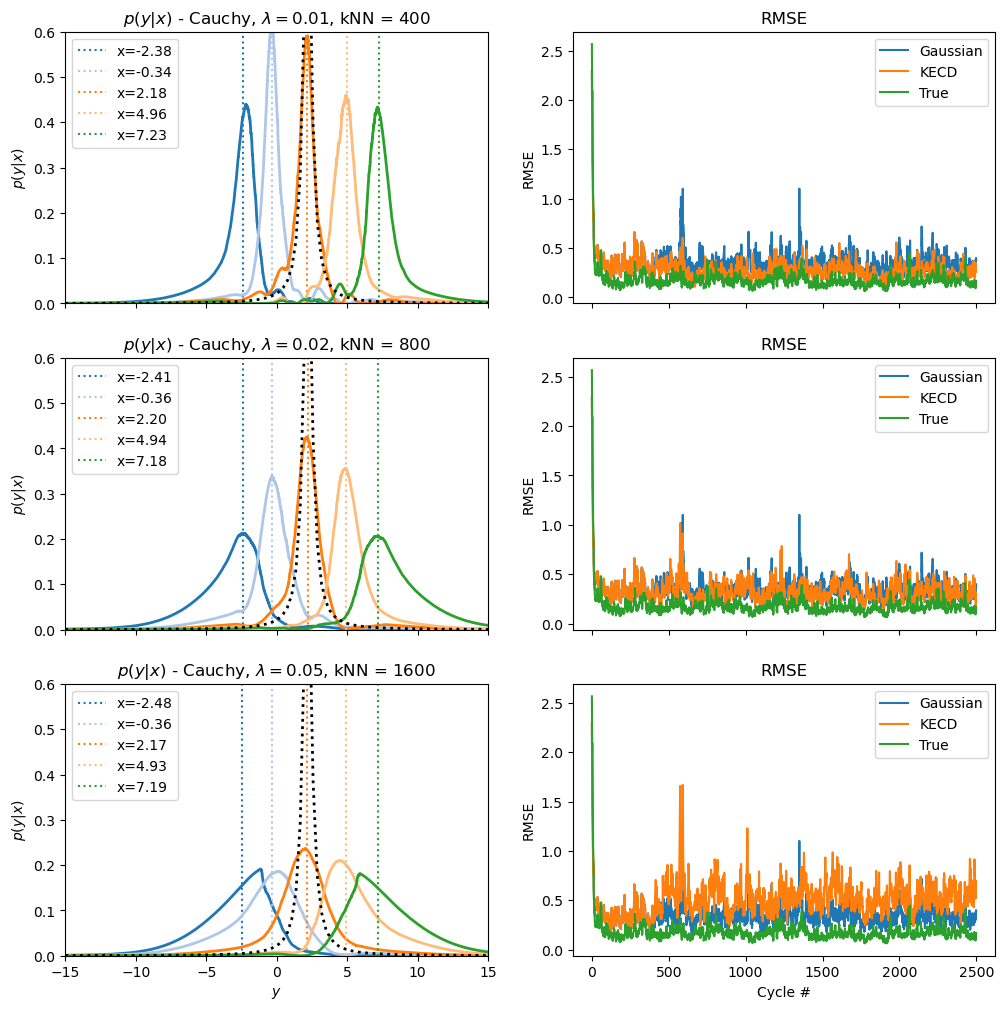

<Figure size 640x480 with 0 Axes>

In [80]:

fig, axs = plt.subplots(3,2, figsize=(12,12), sharey='col', sharex='col')
dap.plot_pab(e_ch_kecd, ax=axs[1,0], plot_states=True)
axs[1,0].set_title('$p(y|x)$ - Cauchy, $\\lambda = 0.02$, kNN = 800')
axs[1,0].plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.20, scale=0.34), linewidth=2, linestyle='dotted', c='k')
dap.plot_pab(e_ch_kecd_small, ax=axs[0,0], plot_states=True)
axs[0,0].set_title('$p(y|x)$ - Cauchy, $\\lambda = 0.01$, kNN = 400')
axs[0,0].plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.18, scale=0.34), linewidth=2, linestyle='dotted', c='k')
dap.plot_pab(e_ch_kecd_big, ax=axs[2,0], plot_states=True)
axs[2,0].set_title('$p(y|x)$ - Cauchy, $\\lambda = 0.05$, kNN = 1600')
axs[2,0].plot(np.linspace(-15, 15, 100), cauchy.pdf(np.linspace(-15, 15, 100), loc=2.17, scale=0.34), linewidth=2, linestyle='dotted', c='k')

axs[1,1].plot(e_ch_gaussian.rmse, label='Gaussian')
axs[1,1].plot(e_ch_kecd.rmse, label='KECD')
axs[1,1].plot(e_ch_true.rmse, label='True')
axs[1,1].set_ylabel('RMSE')
axs[1,1].set_title('RMSE')
axs[1,1].legend()
axs[1,0].set_ylim(0,0.6)

axs[0,1].plot(e_ch_gaussian.rmse, label='Gaussian')
axs[0,1].plot(e_ch_kecd_small.rmse, label='KECD')
axs[0,1].plot(e_ch_true.rmse, label='True')
axs[0,1].set_ylabel('RMSE')
axs[0,1].set_title('RMSE')
axs[0,1].legend()

axs[2,1].plot(e_ch_gaussian.rmse, label='Gaussian')
axs[2,1].plot(e_ch_kecd_big.rmse, label='KECD')
axs[2,1].plot(e_ch_true.rmse, label='True')
axs[2,1].set_ylabel('RMSE')
axs[2,1].set_title('RMSE')
axs[2,1].legend()

axs[2,1].set_xlabel('Cycle #')
axs[1,0].set_xlim(-15, 15)
axs[1,0].set_xlabel('')
axs[0,0].set_xlabel('')

#axs[2,1].set_ylabel('RMSE')
#axs[2,1].set_title('RMSE - Cauchy, Poor Tuning')
#axs[2,1].legend()

fig.savefig('l96_chbigsmall_paper.png')

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Cauchy'}, xlabel='$y$', ylabel='$p(y | x)$'>

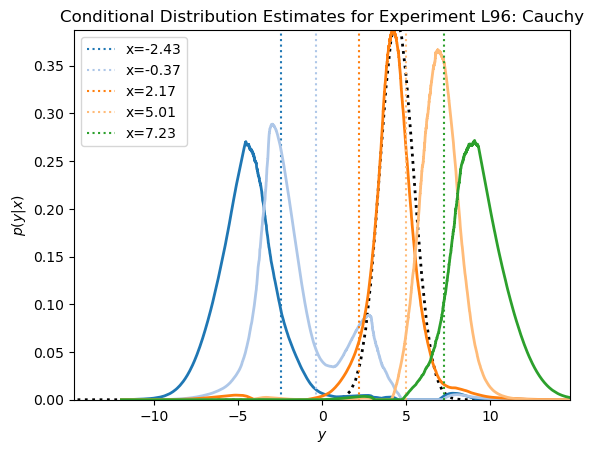

<Figure size 640x480 with 0 Axes>

In [60]:
fig, ax = plt.subplots()
ax.plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=4.42, scale=1), linewidth=2, linestyle='dotted', c='k')
dap.plot_pab(e_sd_kecd, ax=ax, plot_states=True)

In [24]:
_, xt, y = e_sd_kecd.getStates()

In [ ]:
xt.shape

In [ ]:
y.shape

In [ ]:
errs = y[:,:,0] - xt

In [ ]:
np.std(errs, ddof=1)

In [6]:
from scipy.stats import logistic

In [25]:
e_sd_kecd.getParam('status')

'init'

In [77]:
smaller_spread_cauchy_rmse_e_ch_kecd = e_ch_kecd.rmse[1500:].mean()
smaller_spread_cauchy_rmse_e_ch_kecd_small = e_ch_kecd_small.rmse[1500:].mean()
smaller_spread_cauchy_rmse_e_ch_kecd_big = e_ch_kecd_big.rmse[1500:].mean()

In [79]:
print(smaller_spread_cauchy_rmse_e_ch_kecd_small)
print(smaller_spread_cauchy_rmse_e_ch_kecd)
print(smaller_spread_cauchy_rmse_e_ch_kecd_big)

0.2552245174388452
0.31381079598561584
0.5299046051931482
